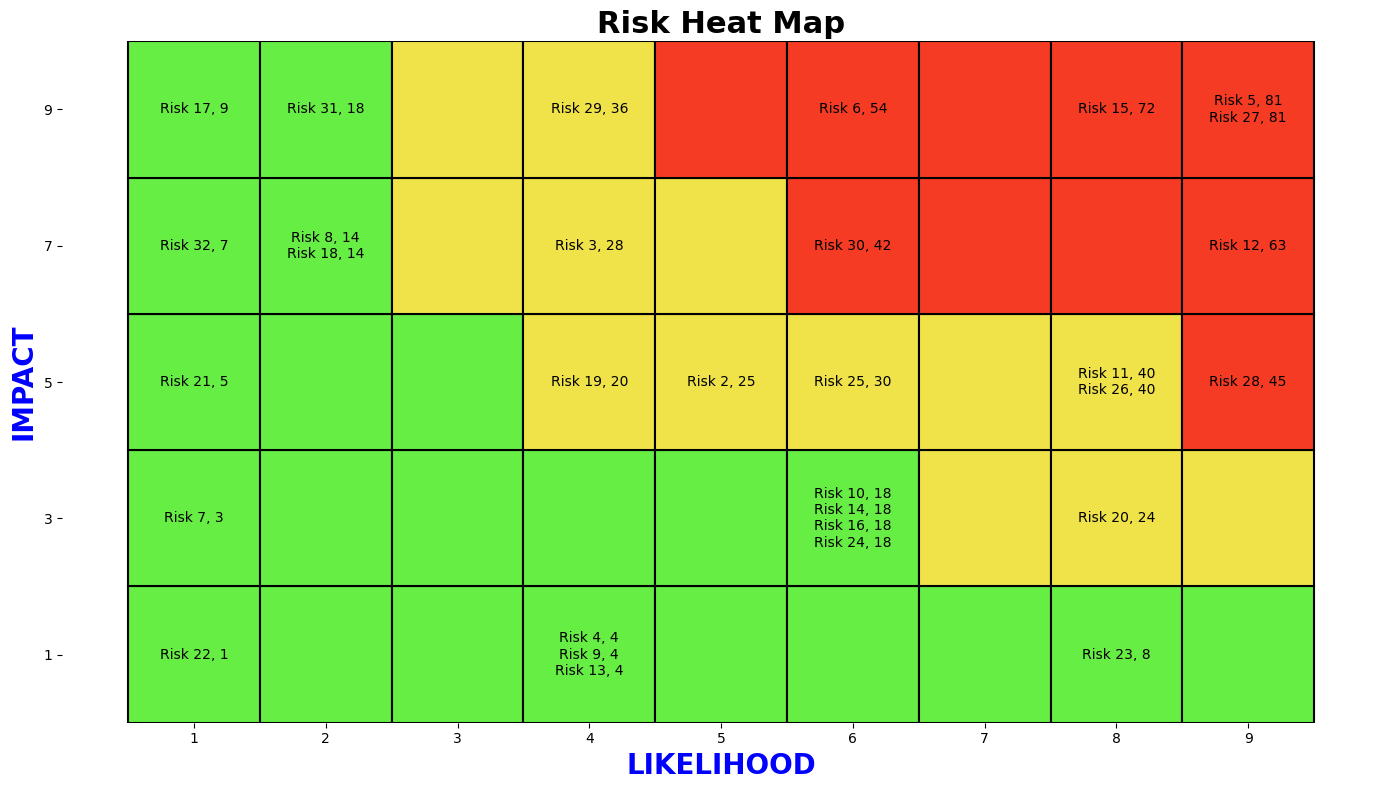

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import defaultdict

# -----------------------------
# RISK DATA
# -----------------------------
risks = [
("Risk 1",7,8),("Risk 2",5,5),("Risk 3",4,7),("Risk 4",4,1),
("Risk 5",9,9),("Risk 6",6,9),("Risk 7",1,3),("Risk 8",2,7),
("Risk 9",4,1),("Risk 10",6,3),("Risk 11",8,5),("Risk 12",9,7),
("Risk 13",4,1),("Risk 14",6,3),("Risk 15",8,9),("Risk 16",6,3),
("Risk 17",1,9),("Risk 18",2,7),("Risk 19",4,5),("Risk 20",8,3),
("Risk 21",1,5),("Risk 22",1,1),("Risk 23",8,1),("Risk 24",6,3),
("Risk 25",6,5),("Risk 26",8,5),("Risk 27",9,9),("Risk 28",9,5),
("Risk 29",4,9),("Risk 30",6,7),("Risk 31",2,9),("Risk 32",1,7)
]

# --------------------------------
# HEATMAP SCALE
# --------------------------------
likelihood_values = [1,2,3,4,5,6,7,8,9]
impact_values = [1,3,5,7,9]

# --------------------------------
# COLOR RULES
# --------------------------------
def cell_color(likelihood, impact):
    score = likelihood * impact
    if score <= 18:
        return "#66ee44"
    elif score <= 40:
        return "#f0e34a"
    else:
        return "#f53b24"

# --------------------------------
# GROUP RISKS INTO CELLS
# --------------------------------
cell_text = defaultdict(list)

for risk_name, likelihood, impact in risks:
    score = likelihood * impact
    cell_text[(likelihood, impact)].append(f"{risk_name}, {score}")

# --------------------------------
# CREATE FIGURE
# --------------------------------
fig, ax = plt.subplots(figsize=(14,8))

for x in likelihood_values:
    for y in impact_values:

        rect = Rectangle(
            (x-0.5, y-1),
            1,
            2,
            facecolor=cell_color(x,y),
            edgecolor="black",
            linewidth=1.5
        )

        ax.add_patch(rect)

        if (x,y) in cell_text:

            text = "\n".join(cell_text[(x,y)])

            ax.text(
                x,
                y,
                text,
                ha='center',
                va='center',
                fontsize=10
            )

# --------------------------------
# AXIS SETTINGS
# --------------------------------
ax.set_xlim(0,10)
ax.set_ylim(0,10)

ax.set_xticks(likelihood_values)
ax.set_yticks(impact_values)

ax.set_xlabel("LIKELIHOOD", fontsize=20, color="blue", fontweight="bold")
ax.set_ylabel("IMPACT", fontsize=20, color="blue", fontweight="bold")

plt.title("Risk Heat Map", fontsize=22, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()